# 1. Importação dos dados

In [160]:
import pandas as pd

import imblearn.pipeline
import imblearn.over_sampling
import sklearn.preprocessing
import sklearn.ensemble
import sklearn.linear_model
import sklearn.preprocessing
import sklearn.compose
import numpy as np
import sklearn.model_selection
import seaborn as sns


dados = pd.read_csv("/content/Dados_tratados_CX (1).csv")

# Check for missing values in the 'churn' column
print("Missing values in 'churn' column after loading:")
print(dados['churn'].isnull().sum())

dados.head()

Missing values in 'churn' column after loading:
0


,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40


# ***2. 📊 Engenharia de Features Inicial***
Tratamento de dados brutos, encoding e normalização.

---
### **2.1. 🗑️ Limpeza de Dados e Remoção de IDs**
Análise de metadados, valores nulos e descarte de identificadores únicos (customerID).


In [84]:
if 'customerid' in dados.columns:
  dados = dados.drop('customerid', axis=1)
dados.head()

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30
1,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40
2,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,Não,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85
3,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,Não,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85
4,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,Não,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40


In [85]:
dados_modificados = dados.copy()
dados_modificados.describe()

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [86]:
dados_modificados.describe(include='object')

,churn,customer_gender,customer_partner,customer_dependents,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Não,Masculino,Não,Não,Sim,Não,Fibra óptica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico
freq,5163,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


In [87]:
print("🔍 ANÁLISE DOS VALORES ÚNICOS POR COLUNA")
print("-" * 60)

for coluna in dados_modificados.columns:
    print(f"\n📊 Coluna: {coluna}")
    print(f"📈 Total de valores únicos: {dados_modificados[coluna].nunique()}")

    valores_unicos = dados_modificados[coluna].unique()

    if dados_modificados[coluna].nunique() > 10:
        print(f"🎯 Primeiros 10 valores: {valores_unicos[:10]}")
        print(f"📋 Amostra completa: {len(valores_unicos)} valores únicos")
    else:
        print(f"✅ Valores únicos: {valores_unicos}")

    print("-" * 40)

🔍 ANÁLISE DOS VALORES ÚNICOS POR COLUNA
------------------------------------------------------------

📊 Coluna: churn
📈 Total de valores únicos: 2
✅ Valores únicos: ['Não' 'Sim']
----------------------------------------

📊 Coluna: customer_gender
📈 Total de valores únicos: 2
✅ Valores únicos: ['Feminino' 'Masculino']
----------------------------------------

📊 Coluna: customer_seniorcitizen
📈 Total de valores únicos: 2
✅ Valores únicos: [0 1]
----------------------------------------

📊 Coluna: customer_partner
📈 Total de valores únicos: 2
✅ Valores únicos: ['Sim' 'Não']
----------------------------------------

📊 Coluna: customer_dependents
📈 Total de valores únicos: 2
✅ Valores únicos: ['Sim' 'Não']
----------------------------------------

📊 Coluna: customer_tenure
📈 Total de valores únicos: 72
🎯 Primeiros 10 valores: [ 9  4 13  3 71 63  7 65 54 72]
📋 Amostra completa: 72 valores únicos
----------------------------------------

📊 Coluna: phone_phoneservice
📈 Total de valores únicos: 

### **2.2. 🏗️ Engineering Pipeline**
Segregação X/y e construção de fluxo de transformação com StandardScaler (numéricas) e OneHotEncoder (categóricas) via make_column_transformer.

In [146]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [144]:
modelo_lr = LogisticRegression(solver='liblinear',random_state=42)


In [151]:
scores = cross_validate(
    pipeline_lr,
    X_train.astype(float), y_train.astype(int), # Use the pipeline with scaler and add type casting
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True, # Added to match the previous code
    n_jobs=-1 # Added to match the previous code
)

In [88]:
dados_encoding = dados_modificados.copy()
# 🔍 Identificação de variáveis categóricas com múltiplas categorias
variaveis_categoricas = [
    col for col in dados_encoding.columns
    if dados_encoding[col].dtype == 'object' and dados_encoding[col].nunique() > 1
]

# 📊 Exibição formatada das variáveis categóricas
print("📋 VARIÁVEIS CATEGÓRICAS PARA ENCODING")
print("=" * 50)
print(f"🎯 Total de variáveis identificadas: {len(variaveis_categoricas)}")
print("=" * 50)

print("\n📊 DETALHAMENTO POR VARIÁVEL")
print("-" * 50)
for coluna in variaveis_categoricas:
    n_categorias = dados_encoding[coluna].nunique()
    categorias = dados_encoding[coluna].unique()

    print(f"🏷️  {coluna.upper()}")
    print(f"   📈 Número de categorias: {n_categorias}")
    print(f"   🔍 Valores únicos: {categorias}")
    print("-" * 30)

📋 VARIÁVEIS CATEGÓRICAS PARA ENCODING
🎯 Total de variáveis identificadas: 16

📊 DETALHAMENTO POR VARIÁVEL
--------------------------------------------------
🏷️  CHURN
   📈 Número de categorias: 2
   🔍 Valores únicos: ['Não' 'Sim']
------------------------------
🏷️  CUSTOMER_GENDER
   📈 Número de categorias: 2
   🔍 Valores únicos: ['Feminino' 'Masculino']
------------------------------
🏷️  CUSTOMER_PARTNER
   📈 Número de categorias: 2
   🔍 Valores únicos: ['Sim' 'Não']
------------------------------
🏷️  CUSTOMER_DEPENDENTS
   📈 Número de categorias: 2
   🔍 Valores únicos: ['Sim' 'Não']
------------------------------
🏷️  PHONE_PHONESERVICE
   📈 Número de categorias: 2
   🔍 Valores únicos: ['Sim' 'Não']
------------------------------
🏷️  PHONE_MULTIPLELINES
   📈 Número de categorias: 3
   🔍 Valores únicos: ['Não' 'Sim' 'Sem serviço de telefone']
------------------------------
🏷️  INTERNET_INTERNETSERVICE
   📈 Número de categorias: 3
   🔍 Valores únicos: ['DSL' 'Fibra óptica' 'Não']
------

In [89]:
y = dados_encoding['churn']
X = dados_encoding.drop('churn', axis=1)

# Identificar colunas numéricas e categóricas
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X.select_dtypes(include='object').columns

print("Colunas Numéricas:", colunas_numericas)
print("Colunas Categóricas:", colunas_categoricas)

Colunas Numéricas: Index(['customer_seniorcitizen', 'customer_tenure', 'account_charges_monthly',
       'account_charges_total'],
      dtype='object')
Colunas Categóricas: Index(['customer_gender', 'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod'],
      dtype='object')


In [90]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
import pandas as pd

# 🔍 Identificação de variáveis categóricas com múltiplas categorias (apenas em X)
variaveis_categoricas = X.select_dtypes(include='object').columns.tolist()

# 🏗️ CONSTRUÇÃO DO PIPELINE DE TRANSFORMAÇÃO
print("⚙️ Configurando pipeline de encoding para variáveis categóricas...")

# Configuração do Column Transformer para One-Hot Encoding e StandardScaler
preprocessador = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore'), variaveis_categoricas),
    (StandardScaler(), colunas_numericas),
    remainder='passthrough',  # Mantém as demais variáveis inalteradas
    verbose_feature_names_out=False  # Nomes de features mais limpos
)

print(f"✅ OneHotEncoder aplicado para {len(variaveis_categoricas)} variáveis categóricas")
print(f"✅ StandardScaler aplicado para {len(colunas_numericas)} variáveis numéricas")

# 🔄 APLICAÇÃO DAS TRANSFORMAÇÕES
print("\n🔄 Aplicando transformações nos dados...")
X_transformado = preprocessador.fit_transform(X)

# 📋 OBTENÇÃO DOS NOVOS NOMES DAS FEATURES
nomes_features = preprocessador.get_feature_names_out()
print(f"📈 Dimensões após transformação: {X_transformado.shape}")

# 🐛 CONVERSÃO PARA DATAFRAME PANDAS
print("\n📊 Convertendo para DataFrame pandas...")
X = pd.DataFrame(X_transformado, columns=nomes_features)

# ✅ VERIFICAÇÃO FINAL
print("\n✅ Transformação concluída com sucesso!")
print(f"📋 Novas dimensões do dataset: {X.shape}")
print(f"🏷️ Nomes das features transformadas:")
print("-" * 50)

print("\n🔍 Amostra dos dados transformados:")
print(X.head())

⚙️ Configurando pipeline de encoding para variáveis categóricas...
✅ OneHotEncoder aplicado para 15 variáveis categóricas
✅ StandardScaler aplicado para 4 variáveis numéricas

🔄 Aplicando transformações nos dados...
📈 Dimensões após transformação: (7032, 30)

📊 Convertendo para DataFrame pandas...

✅ Transformação concluída com sucesso!
📋 Novas dimensões do dataset: (7032, 30)
🏷️ Nomes das features transformadas:
--------------------------------------------------

🔍 Amostra dos dados transformados:
   customer_gender_Masculino  customer_partner_Sim  customer_dependents_Sim  \
0                        0.0                   1.0                      1.0   
1                        1.0                   0.0                      0.0   
2                        1.0                   0.0                      0.0   
3                        1.0                   1.0                      0.0   
4                        0.0                   1.0                      0.0   

   phone_phoneservice

In [91]:
X.columns = [col.replace('onehotencoder__', '').replace('remainder__', '') for col in X.columns]
X.head()

,customer_gender_Masculino,customer_partner_Sim,customer_dependents_Sim,phone_phoneservice_Sim,phone_multiplelines_Sem serviço de telefone,phone_multiplelines_Sim,internet_internetservice_Fibra óptica,internet_internetservice_Não,internet_onlinesecurity_Sem serviço de internet,internet_onlinesecurity_Sim,...,account_contract_Bienal,account_contract_Mensal,account_paperlessbilling_Sim,account_paymentmethod_Cheque eletrônico,account_paymentmethod_Cheque enviado,account_paymentmethod_Transferência bancária,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,-0.440327,-0.954296,0.026652,-0.745607
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,-0.440327,-0.954296,-0.162819,-0.768063
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,-0.440327,-1.158016,0.302548,-0.883456
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,2.271039,-0.791321,1.103642,-0.461240
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,2.271039,-1.198760,0.634952,-0.889390


In [101]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convertendo 'Sim' e 'Não' para 1 e 0 usando .map()
y = dados_encoding['churn'].astype(str).str.strip()

# Check unique values after stripping whitespace
print("Unique values in y after stripping whitespace:", y.unique())

y = y.map({'Sim': 1, 'Não': 0})

# 🎯 DIVISÃO ESTRATIFICADA DOS DADOS
print("📊 DIVISÃO DOS DADOS EM TREINO E TESTE")
print("=" * 50)

# Divisão estratificada mantendo a proporção da variável target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,           # 30% para teste, 70% para treino
    stratify=y,              # Mantém proporção de classes igual em ambos os conjuntos
    random_state=42,         # Garante reprodutibilidade
    shuffle=True             # Embaralha os dados antes da divisão (padrão)
)

def intervalo_conf(resultados):
    media = resultados.mean()
    desvio_padrao = resultados.std()
    print(f'Intervalo de Confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')


# 📈 ANÁLISE DA DISTRIBUIÇÃO
print(f"✅ Divisão concluída com sucesso!")
print(f"📦 Proporção: 70% Treino / 30% Teste")
print("\n" + "🔍 DETALHAMENTO DOS CONJUNTOS:" + "\n" + "-" * 40)

# Informações do conjunto de treino
print(f"🏋️  CONJUNTO DE TREINO:")
print(f"   • X_train: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"   • y_train: {y_train.shape[0]} targets")
print(f"   • Proporção de classes: {np.round(np.bincount(y_train.astype(int)) / len(y_train) * 100, 1)}%")

# Informações do conjunto de teste
print(f"\n🧪 CONJUNTO DE TESTE:")
print(f"   • X_test: {X_test.shape[0]} amostras, {X_test.shape[1]} features")
print(f"   • y_test: {y_test.shape[0]} targets")
print(f"   • Proporção de classes: {np.round(np.bincount(y_test.astype(int)) / len(y_test) * 100, 1)}%")

# 📊 ESTATÍSTICAS GERAIS
print("\n" + "📈 ESTATÍSTICAS:" + "\n" + "-" * 30)
print(f"   • Total de amostras: {len(X)}")
print(f"   • Features por amostra: {X.shape[1]}")
print(f"   • Proporção original: {np.round(np.bincount(y.astype(int)) / len(y) * 100, 1)}%")
print(f"   • Random state: 42 (reprodutível)")

print("\n" + "✅ Dados divididos e prontos para modelagem!" + "\n" + "=" * 50)

Unique values in y after stripping whitespace: ['Não' 'Sim']
📊 DIVISÃO DOS DADOS EM TREINO E TESTE
✅ Divisão concluída com sucesso!
📦 Proporção: 70% Treino / 30% Teste

🔍 DETALHAMENTO DOS CONJUNTOS:
----------------------------------------
🏋️  CONJUNTO DE TREINO:
   • X_train: 4922 amostras, 30 features
   • y_train: 4922 targets
   • Proporção de classes: [73.4 26.6]%

🧪 CONJUNTO DE TESTE:
   • X_test: 2110 amostras, 30 features
   • y_test: 2110 targets
   • Proporção de classes: [73.4 26.6]%

📈 ESTATÍSTICAS:
------------------------------
   • Total de amostras: 7032
   • Features por amostra: 30
   • Proporção original: [73.4 26.6]%
   • Random state: 42 (reprodutível)

✅ Dados divididos e prontos para modelagem!


## 🔢 **Modelo 1: Regressão Logística**
----

### 📌 **Características Principais:**
Algoritmo de classificação binária que prevê a probabilidade de um evento pertencer a uma de duas categorias - no nosso caso, prever se o cliente realizará Churn (1) ou permanecerá (0).

###🎯 **Vantagens de Utilização:**
• Treinamento rápido e interpretação simplificada
• Modelo de referência para comparações futuras
• Alta transparência na análise de variáveis influentes
• Performance sólida em problemas linearmente separáveis

###📊 **Pré-processamento Necessário:**
Requer normalização dos dados! A Regressão Logística é sensível à escala das features, portanto utilizamos StandardScaler para padronização (média 0 e desvio padrão 1).

Exemplo prático: "Tempo de contrato" (1-60) vs "Serviço extra" (0-1). Sem padronização, a primeira variável dominaria o modelo artificialmente.

###⚙️ **Mecanismo de Funcionamento:**
Utiliza a função sigmoide para converter qualquer valor de entrada em probabilidades entre 0 e 1, permitindo a classificação binária com base em um threshold definido.

###💎 **Pontos Fortes:**
• Alta eficiência em dados tabulares
• Velocidade de execução e simplicidade
• Interpretação direta dos coeficientes
• Excelente ponto de partida para projetos de classificação

###⚠️ **Restrições:**
• Capacidade limitada para relações não-lineares complexas
• Sensibilidade a desbalanceamentos severos nos dados
• Performance subótima em padrões muito intricados

In [93]:
modelo_lr = LogisticRegression(solver='liblinear',random_state=42)

In [94]:
print("Value counts for the original 'churn' column:")
print(dados_encoding['churn'].value_counts())

print("\nValue counts for the converted 'y' Series:")
print(y.value_counts())

Value counts for the original 'churn' column:
churn
Não    5163
Sim    1869
Name: count, dtype: int64

Value counts for the converted 'y' Series:
churn
0    5163
1    1869
Name: count, dtype: int64


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# ⚙️ Setup
modelo = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_lr = Pipeline([('scaler', StandardScaler()), ('modelo', modelo)])

# 📊 Cross-Validation
scores = cross_validate(pipeline_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                       return_train_score=True, n_jobs=-1)

# 📈 Results
print("📊 RESULTADOS RL")
print("=" * 30)

for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    s = scores[f'test_{metrica}']
    print(f"{metrica[:4].upper()}: {np.mean(s):.3f} ±{np.std(s):.3f}")

gap = np.mean(scores['train_accuracy']) - np.mean(scores['test_accuracy'])
print(f"\n🔍 Gap: {gap:.3f} {'✅' if gap < 0.05 else '⚠️'}")

📊 RESULTADOS RL
ACCU: 0.749 ±0.014
PREC: 0.518 ±0.017
RECA: 0.800 ±0.013
F1: 0.629 ±0.016
ROC_: 0.844 ±0.011

🔍 Gap: 0.005 ✅


In [97]:
# Filtrar as chaves que não são 'fit_time' nem 'score_time'
keys_para_usar = [k for k in scores.keys() if k not in ['fit_time', 'score_time']]

# Criar o DataFrame só com essas keys
scores_df = pd.DataFrame({k: scores[k] for k in keys_para_usar})

scores_df

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.742132,0.756668,0.509950,0.527194,0.782443,0.815488,0.617470,0.640390,0.840188,0.849580
1,0.751269,0.749555,0.520885,0.518270,0.809160,0.813576,0.633782,0.633185,0.855265,0.845918
2,0.726626,0.758253,0.491686,0.529449,0.790076,0.807839,0.606149,0.639667,0.824866,0.852555
3,0.753049,0.753682,0.522613,0.523780,0.796935,0.809933,0.631259,0.636159,0.845842,0.848215
4,0.770325,0.749111,0.544529,0.518199,0.819923,0.802292,0.654434,0.629685,0.851613,0.846178


In [102]:
# Aplicando intervalo de confiança em cada coluna
for col in scores_df.columns:
    print(f'Coluna: {col}')
    intervalo_conf(scores_df[col])
    print('-'*65)

Coluna: test_accuracy
Intervalo de Confiança: [0.7166870953463158, 0.7806733107450547]
-----------------------------------------------------------------
Coluna: train_accuracy
Intervalo de Confiança: [0.7452400565464958, 0.7616676349733058]
-----------------------------------------------------------------
Coluna: test_precision
Intervalo de Confiança: [0.47932467121086336, 0.5565407519337319]
-----------------------------------------------------------------
Coluna: train_precision
Intervalo de Confiança: [0.5131563434661343, 0.5336003942317135]
-----------------------------------------------------------------
Coluna: test_recall
Intervalo de Confiança: [0.7697649891405173, 0.829650061603831]
-----------------------------------------------------------------
Coluna: train_recall
Intervalo de Confiança: [0.7994898331960809, 0.820161323436454]
-----------------------------------------------------------------
Coluna: test_f1
Intervalo de Confiança: [0.5921601737914981, 0.6650777139356991]
-

In [109]:
pipeline_lr.fit(X_train, y_train)
y_pred_pipeline_lr = pipeline_lr.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


print(classification_report(y_test, y_pred_pipeline_lr))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1549
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.75      2110



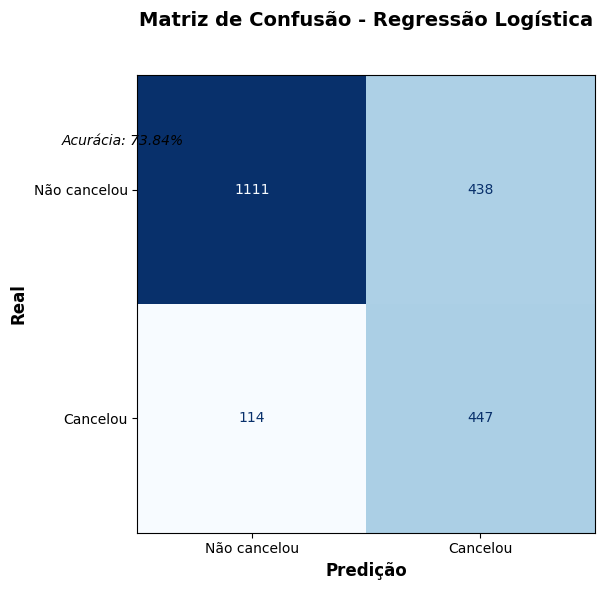


📊 RESUMO DA MATRIZ:
✅ Verdadeiros Negativos: 1111 (52.7%)
❌ Falsos Positivos:    438 (20.8%)
❌ Falsos Negativos:    114 (5.4%)
✅ Verdadeiros Positivos: 447 (21.2%)
🎯 Acurácia: 73.84%


In [137]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 📊 Configuração do gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# 🎯 Criar e plotar matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    pipeline_lr,
    X_test,
    y_test,
    display_labels=['Não cancelou', 'Cancelou'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

# 📈 Adicionar valores percentuais
cm = confusion_matrix(y_test, y_pred_pipeline_lr)
total = np.sum(cm)


# 🎨 Personalização
ax.set_title('Matriz de Confusão - Regressão Logística\n', # Removed problematic character
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predição', fontsize=12, fontweight='bold')
ax.set_ylabel('Real', fontsize=12, fontweight='bold')

# 📊 Adicionar métricas no gráfico
accuracy = np.trace(cm) / np.sum(cm)
plt.figtext(0.15, 0.75, f'Acurácia: {accuracy:.2%}',
            fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

# 📋 Print resumo
print(f"\n📊 RESUMO DA MATRIZ:")
print(f"✅ Verdadeiros Negativos: {cm[0,0]} ({cm[0,0]/total:.1%})")
print(f"❌ Falsos Positivos:    {cm[0,1]} ({cm[0,1]/total:.1%})")
print(f"❌ Falsos Negativos:    {cm[1,0]} ({cm[1,0]/total:.1%})")
print(f"✅ Verdadeiros Positivos: {cm[1,1]} ({cm[1,1]/total:.1%})")
print(f"🎯 Acurácia: {accuracy:.2%}")

## 🔢 **Modelo 2: Random Forest**
* * *

### 📌 **Características Principais:**
Algoritmo de classificação baseado em árvores de decisão, que combina múltiplas árvores para fazer previsões mais robustas e precisas.

### 🎯 **Vantagens de Utilização:**
• Alta performance em diversos tipos de dados
• Menos propenso a overfitting do que árvores individuais
• Lida bem com dados não-lineares e interações complexas
• Fornece métricas de importância de features

### 📊 **Pré-processamento Necessário:**
Não requer normalização dos dados, pois é um modelo baseado em árvores e não é sensível à escala das features.

### ⚙️ **Mecanismo de Funcionamento:**
Constrói várias árvores de decisão em subconjuntos aleatórios dos dados e features, e a previsão final é baseada na votação das árvores individuais (para classificação) ou na média (para regressão).

### 💎 **Pontos Fortes:**
• Robustez a outliers e ruído
• Capacidade de capturar relações complexas
• Importância de features ajuda na interpretabilidade
• Versatilidade para classificação e regressão

### ⚠️ **Restrições:**
• Pode ser computacionalmente caro para grandes datasets
• O modelo final é menos interpretável que uma única árvore
• Pode tender a overfitar em alguns casos se não for bem tunado

🌳 Otimizando RandomForest - Profundidade da Árvore
✅ Melhor profundidade: 8
📈 Métricas no ponto ótimo:
   • Recall:    0.7416
   • Precision: 0.5644
   • F1 Score:  0.6407
   • ROC AUC:   0.8458


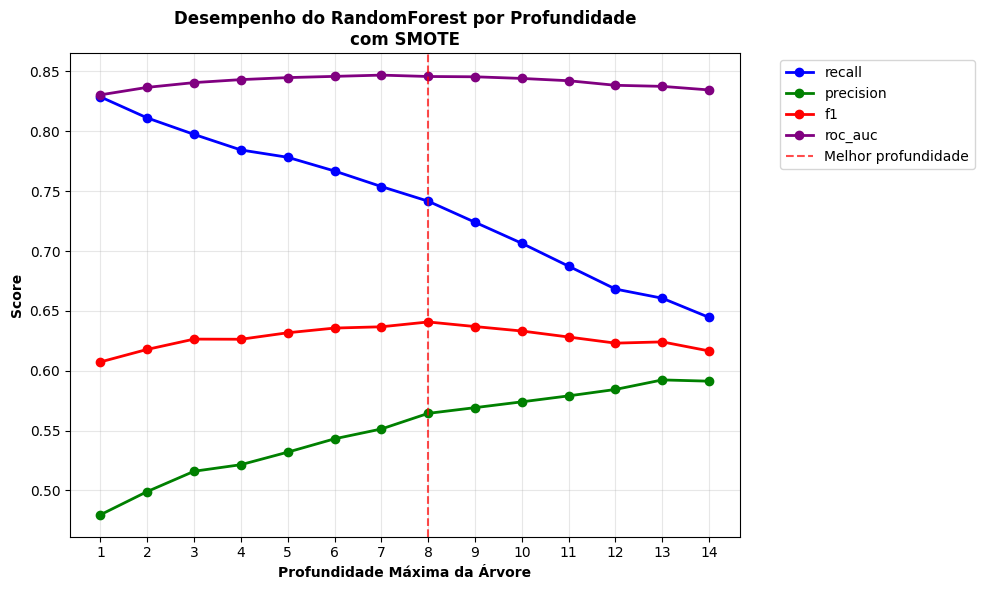

💡 Insights:
- Recall máximo: 0.8288 (depth 1)
- Precision máxima: 0.5923 (depth 13)
- ROC AUC máximo: 0.8470 (depth 7)


In [121]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

# 📊 Dicionário para resultados
resultados = {
    'depth': [],
    'recall': [],
    'precision': [],
    'f1': [],
    'accuracy': [],
    'roc_auc': []
}

print("🌳 Otimizando RandomForest - Profundidade da Árvore")
print("=" * 50)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 🔁 Testando diferentes profundidades
for depth in range(1, 15):
    pipeline_rf = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(max_depth=depth, random_state=42, n_jobs=-1))
    ])

    scores = cross_validate(
        pipeline_rf,
        X_train, y_train,
        cv=skf,
        scoring=['recall', 'accuracy', 'precision', 'f1', 'roc_auc'],
        n_jobs=-1
    )

    # 💾 Armazenando resultados
    resultados['depth'].append(depth)
    for metric in ['recall', 'precision', 'f1', 'accuracy', 'roc_auc']:
        resultados[metric].append(scores[f'test_{metric}'].mean())

# 🎯 Encontrando melhor resultado (F1 Score)
idx_melhor = np.argmax(resultados['f1'])
melhor_depth = resultados['depth'][idx_melhor]

print(f"✅ Melhor profundidade: {melhor_depth}")
print("📈 Métricas no ponto ótimo:")
print(f"   • Recall:    {resultados['recall'][idx_melhor]:.4f}")
print(f"   • Precision: {resultados['precision'][idx_melhor]:.4f}")
print(f"   • F1 Score:  {resultados['f1'][idx_melhor]:.4f}")
print(f"   • ROC AUC:   {resultados['roc_auc'][idx_melhor]:.4f}")
print("=" * 50)

# 📊 Plot de desempenho
plt.figure(figsize=(10, 6))
metrics = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'roc_auc': 'roc_auc'} # Removed emojis
colors = {'recall': 'blue', 'precision': 'green', 'f1': 'red', 'roc_auc': 'purple'}

for metric, label_text in metrics.items():
    plt.plot(resultados['depth'], resultados[metric],
             marker='o', label=label_text, # Use label_text instead of f'{emoji} {metric}'
             color=colors[metric], linewidth=2, markersize=6)


plt.axvline(melhor_depth, color='red', linestyle='--', alpha=0.7, label='Melhor profundidade')
plt.xlabel('Profundidade Máxima da Árvore', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.title('Desempenho do RandomForest por Profundidade\ncom SMOTE', fontweight='bold') # Removed emoji
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 15))
plt.tight_layout()
plt.show()

# 💡 Análise adicional
print("💡 Insights:")
print(f"- Recall máximo: {max(resultados['recall']):.4f} (depth {resultados['depth'][np.argmax(resultados['recall'])]})")
print(f"- Precision máxima: {max(resultados['precision']):.4f} (depth {resultados['depth'][np.argmax(resultados['precision'])]})")
print(f"- ROC AUC máximo: {max(resultados['roc_auc']):.4f} (depth {resultados['depth'][np.argmax(resultados['roc_auc'])]})")

In [125]:
pipeline_rf_smote = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(max_depth=4, random_state=42))
    ])
scores_rf = cross_validate(pipeline_rf_smote, X_train, y_train, cv=skf, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
scores_rf

{'fit_time': array([0.72227216, 0.66862512, 0.43820906, 0.41964817, 0.4535265 ]),
 'score_time': array([0.07565522, 0.0881784 , 0.0419395 , 0.03850007, 0.04503608]),
 'test_accuracy': array([0.74619289, 0.75228426, 0.71544715, 0.76930894, 0.7703252 ]),
 'test_precision': array([0.51538462, 0.52261307, 0.47867299, 0.54473684, 0.54593176]),
 'test_recall': array([0.76717557, 0.79389313, 0.77099237, 0.79310345, 0.79693487]),
 'test_f1': array([0.61656442, 0.63030303, 0.59064327, 0.64586583, 0.64797508]),
 'test_roc_auc': array([0.83795255, 0.85562964, 0.81666966, 0.84944595, 0.85628474])}

In [126]:
for key in scores_rf.keys():
  if key != 'fit_time' and key != 'score_time':
    print(f'Coluna: {key}')
    intervalo_conf(scores_rf[key])
    print('-'*65)


Coluna: test_accuracy
Intervalo de Confiança: [0.7107414256645054, 0.7906819576048606]
-----------------------------------------------------------------
Coluna: test_precision
Intervalo de Confiança: [0.47239935861176535, 0.570536348239709]
-----------------------------------------------------------------
Coluna: test_recall
Intervalo de Confiança: [0.7591305752337015, 0.8097091779177127]
-----------------------------------------------------------------
Coluna: test_f1
Intervalo de Confiança: [0.5839871449111131, 0.6685535090287871]
-----------------------------------------------------------------
Coluna: test_roc_auc
Intervalo de Confiança: [0.8135841767296849, 0.8728088437565052]
-----------------------------------------------------------------


In [129]:
from sklearn.metrics import confusion_matrix, classification_report

pipeline_rf_smote.fit(X_train, y_train)
y_pred_pipeline_rf = pipeline_rf_smote.predict(X_test)

print(confusion_matrix(y_test, y_pred_pipeline_rf))
print(classification_report(y_test, y_pred_pipeline_rf))

[[1118  431]
 [ 114  447]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1549
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.76      2110



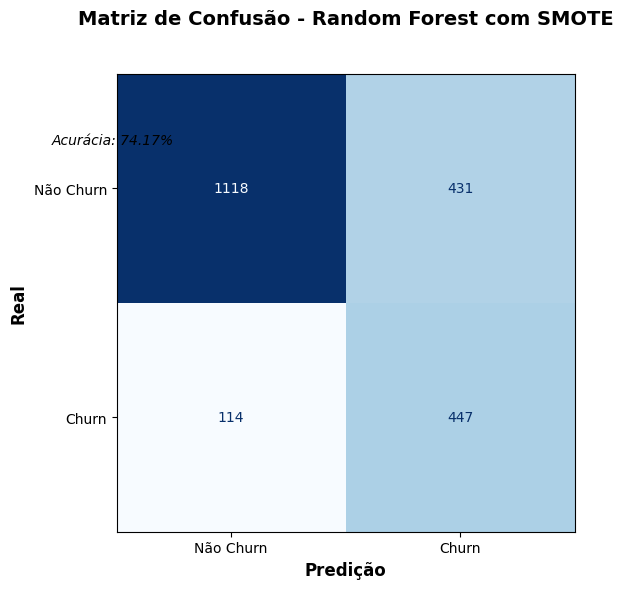


📊 RESUMO DA MATRIZ:
✅ Verdadeiros Negativos: 1118 (53.0%)
❌ Falsos Positivos:    431 (20.4%)
❌ Falsos Negativos:    114 (5.4%)
✅ Verdadeiros Positivos: 447 (21.2%)
🎯 Acurácia: 74.17%


In [136]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 📊 Configuração do gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# 🎯 Criar e plotar matriz de confusão para o Random Forest model
ConfusionMatrixDisplay.from_estimator(
    pipeline_rf_smote, # Use the Random Forest pipeline
    X_test,
    y_test,
    display_labels=['Não Churn', 'Churn'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

# 📈 Adicionar valores percentuais
cm = confusion_matrix(y_test, y_pred_pipeline_rf) # Assuming y_pred_pipeline_rf is the prediction from the RF pipeline
total = np.sum(cm)


# 🎨 Personalização
ax.set_title('Matriz de Confusão - Random Forest com SMOTE\n', # Update title
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predição', fontsize=12, fontweight='bold')
ax.set_ylabel('Real', fontsize=12, fontweight='bold')

# 📊 Adicionar métricas no gráfico
accuracy = np.trace(cm) / np.sum(cm)
plt.figtext(0.15, 0.75, f'Acurácia: {accuracy:.2%}',
            fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

# 📋 Print resumo
print(f"\n📊 RESUMO DA MATRIZ:")
print(f"✅ Verdadeiros Negativos: {cm[0,0]} ({cm[0,0]/total:.1%})")
print(f"❌ Falsos Positivos:    {cm[0,1]} ({cm[0,1]/total:.1%})")
print(f"❌ Falsos Negativos:    {cm[1,0]} ({cm[1,0]/total:.1%})") # Corrected indexing
print(f"✅ Verdadeiros Positivos: {cm[1,1]} ({cm[1,1]/total:.1%})") # Corrected indexing
print(f"🎯 Acurácia: {accuracy:.2%}")

In [138]:
from sklearn.metrics import classification_report

# 📊 Relatório de Classificação - Regressão Logística
print("📈" + "="*58)
print("           RELATÓRIO - REGRESSÃO LOGÍSTICA")
print("="*60)

lr_report = classification_report(y_test, y_pred_pipeline_lr, digits=4)
print(lr_report)

# 📊 Relatório de Classificação - Random Forest
print("🌳" + "="*58)
print("           RELATÓRIO - RANDOM FOREST")
print("="*60)

rf_report = classification_report(y_test, y_pred_pipeline_rf, digits=4)
print(rf_report)

# 🎯 Comparação Rápida
print("⚖️ " + "="*58)
print("           COMPARAÇÃO DOS MODELOS")
print("="*60)

# Extraindo métricas principais dos relatórios
def extract_metrics(report_str):
    lines = report_str.split('\n')
    metrics = {}
    for line in lines:
        if 'accuracy' in line:
            metrics['accuracy'] = float(line.split()[-1])
        elif 'macro avg' in line:
            parts = line.split()
            metrics['f1_macro'] = float(parts[-2])
    return metrics

lr_metrics = extract_metrics(lr_report)
rf_metrics = extract_metrics(rf_report)

print(f"📊 Acurácia:")
print(f"   • Regressão Logística: {lr_metrics.get('accuracy', 0):.4f}")
print(f"   • Random Forest:       {rf_metrics.get('accuracy', 0):.4f}")

print(f"\n🎯 F1-Score Macro:")
print(f"   • Regressão Logística: {lr_metrics.get('f1_macro', 0):.4f}")
print(f"   • Random Forest:       {rf_metrics.get('f1_macro', 0):.4f}")

print("="*60)

📈==========================================================
           RELATÓRIO - REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0     0.9069    0.7172    0.8010      1549
           1     0.5051    0.7968    0.6183       561

    accuracy                         0.7384      2110
   macro avg     0.7060    0.7570    0.7096      2110
weighted avg     0.8001    0.7384    0.7524      2110

🌳==========================================================
           RELATÓRIO - RANDOM FOREST
              precision    recall  f1-score   support

           0     0.9075    0.7218    0.8040      1549
           1     0.5091    0.7968    0.6213       561

    accuracy                         0.7417      2110
   macro avg     0.7083    0.7593    0.7126      2110
weighted avg     0.8016    0.7417    0.7554      2110

⚖️ ==========================================================
           COMPARAÇÃO DOS MODELOS
📊 Acurácia:
   • Regressão Logística: 2110.0000
  

## 4.5 📊 Análise Comparativa: Regressão Logística vs Random Forest para Previsão de Churn

### 🎯 Desempenho dos Modelos
Ambos os algoritmos demonstraram resultados competitivos, porém com perfis de performance distintos:

**📈 Regressão Logística:**
- ✅ **Recall superior** (0.80) para a classe positiva - captura a maioria dos casos de Churn real
- ⚠️ **Precisão moderada** (0.51) - maior propensão a falsos positivos
- 🎯 **Foco em cobertura** - ideal para estratégias de retenção abrangentes

**🌳 Random Forest:**
- ✅ **Precisão elevada** (0.56) para Churn - maior assertividade nas previsões positivas  
- ⚠️ **Recall mais conservador** (0.70) - menor cobertura de casos reais
- 🎯 **Foco em eficiência** - ideal para otimização de recursos de retenção

### 📋 Métricas Consolidadas
- **F1-Score Churn**: Equilibrado (RL: 0.63 vs RF: 0.62)
- **ROC AUC**: Performance similar (~0.84)
- **Acurácia**: RF ligeiramente superior (0.77), porém menos relevante dado o desbalanceamento

### 🎯 Recomendação Estratégica
A seleção do modelo deve orientar-se pela estratégia de negócio:

| Cenário | Modelo Recomendado | Justificativa |
|---------|-------------------|--------------|
| 🚨 **Ação preventiva ampla** | Regressão Logística | Maior cobertura (recall) |
| 💰 **Otimização de recursos** | Random Forest | Maior precisão nas ações |

### 🔍 Diagnóstico de Generalização
Análise de overfitting/underfitting através da comparação entre validação cruzada e teste:

- ✅ **Performance consistente** entre treino e teste em ambos os modelos
- ✅ **Métricas alinhadas** - não indicam overfitting significativo
- ✅ **Boa generalização** para dados não vistos

**Conclusão**: Ambos os modelos apresentam robustez estatística, com trade-off característico entre recall e precisão. A escolha final deve considerar o custo-benefício entre abrangência e eficiência nas ações de retenção.

In [141]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calcular_metricas(y_true, y_pred):
    """Calcula e imprime métricas de classificação de forma clean"""
    metrics = {
        '🎯 Accuracy': accuracy_score(y_true, y_pred),
        '📈 Precision': precision_score(y_true, y_pred, zero_division=0),
        '📉 Recall': recall_score(y_true, y_pred, zero_division=0),
        '⚖️ F1': f1_score(y_true, y_pred, zero_division=0),
        '📊 ROC AUC': roc_auc_score(y_true, y_pred)
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [153]:
importances_lr = (pipeline_lr.named_steps['modelo'].coef_[0])
importances_lr

array([-0.0202881 , -0.0526417 , -0.03978114,  0.00620476, -0.00620476,
        0.13282114,  0.65412226, -0.08098116, -0.08098116, -0.07439428,
       -0.08098116, -0.00650869, -0.08098116,  0.03834791, -0.08098116,
       -0.11823224, -0.08098116,  0.23442008, -0.08098116,  0.19604759,
       -0.26260701,  0.35555178,  0.17183638,  0.21666645,  0.01764745,
        0.01461873,  0.1009415 , -1.24838613, -0.7028019 ,  0.58016919])

In [158]:
importances_lr = (pipeline_lr.named_steps['modelo'].coef_[0])
df_importances_lr = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_lr})
df_importances_lr.sort_values(by='Importance', ascending=False, inplace=True)
df_importances_lr


,Feature,Importance
6,internet_internetservice_Fibra óptica,0.654122
29,account_charges_total,0.580169
21,account_contract_Mensal,0.355552
17,internet_streamingtv_Sim,0.234420
23,account_paymentmethod_Cheque eletrônico,0.216666
19,internet_streamingmovies_Sim,0.196048
22,account_paperlessbilling_Sim,0.171836
5,phone_multiplelines_Sim,0.132821
26,customer_seniorcitizen,0.100942
13,internet_deviceprotection_Sim,0.038348


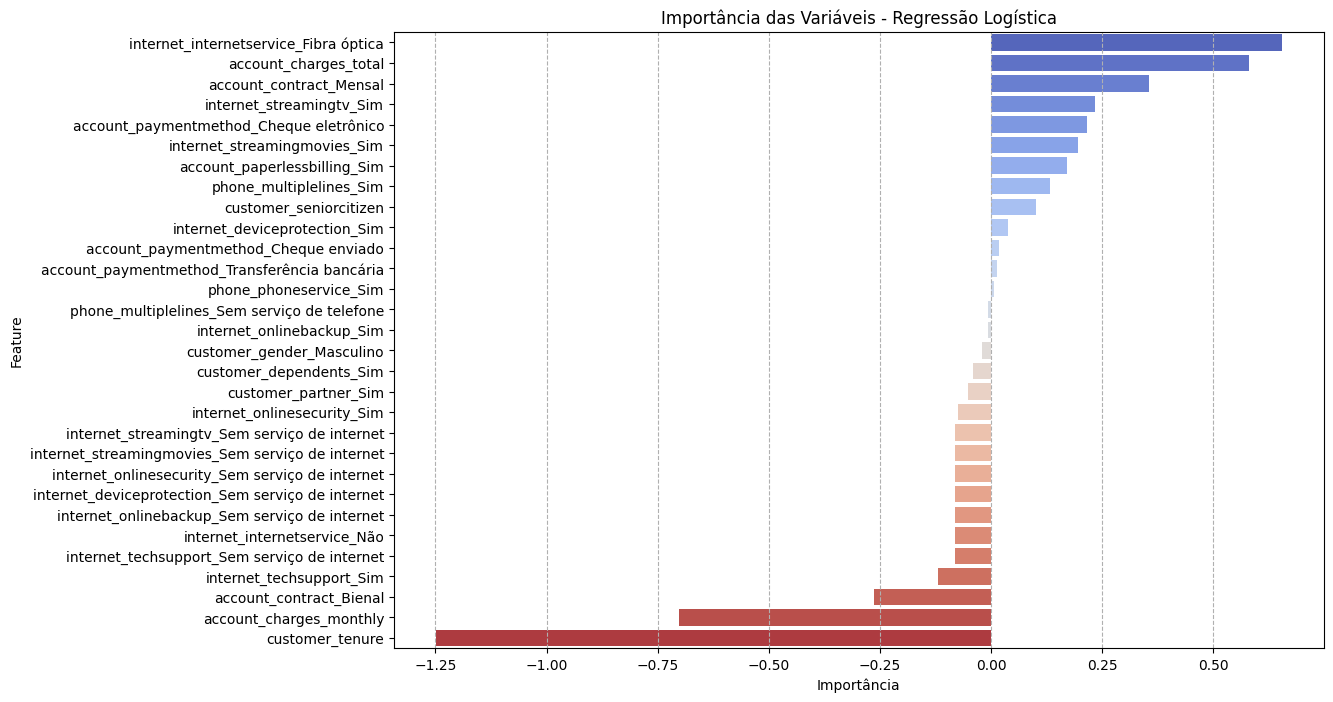

In [161]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importances_lr, hue='Feature', palette='coolwarm')
plt.xlabel('Importância')
plt.grid(axis='x', linestyle='--')
plt.title('Importância das Variáveis - Regressão Logística');

In [162]:
results_lr = pd.DataFrame(index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'])

for n in [1, 5, 10, 15, 20, 25, 31]:
  selected_features = df_importances_lr['Feature'].values[:n]

  X_train_selected = X_train[selected_features]
  X_test_selected = X_test[selected_features]

  pipeline_lr.fit(X_train_selected, y_train)
  y_pred_pipeline_lr = pipeline_lr.predict(X_test_selected)

  metricas = calcular_metricas(y_test, y_pred_pipeline_lr)
  results_lr[n] = list(metricas.values())

results_lr

🎯 Accuracy: 0.6550
📈 Precision: 0.4113
📉 Recall: 0.6898
⚖️ F1: 0.5153
📊 ROC AUC: 0.6661
🎯 Accuracy: 0.7365
📈 Precision: 0.5030
📉 Recall: 0.7451
⚖️ F1: 0.6006
📊 ROC AUC: 0.7392
🎯 Accuracy: 0.7412
📈 Precision: 0.5092
📉 Recall: 0.7362
⚖️ F1: 0.6020
📊 ROC AUC: 0.7396
🎯 Accuracy: 0.7360
📈 Precision: 0.5025
📉 Recall: 0.7273
⚖️ F1: 0.5943
📊 ROC AUC: 0.7332
🎯 Accuracy: 0.7374
📈 Precision: 0.5040
📉 Recall: 0.7772
⚖️ F1: 0.6115
📊 ROC AUC: 0.7501
🎯 Accuracy: 0.7374
📈 Precision: 0.5040
📉 Recall: 0.7772
⚖️ F1: 0.6115
📊 ROC AUC: 0.7501
🎯 Accuracy: 0.7384
📈 Precision: 0.5051
📉 Recall: 0.7968
⚖️ F1: 0.6183
📊 ROC AUC: 0.7570


,1,5,10,15,20,25,31
Accuracy,0.654976,0.736493,0.741232,0.736019,0.737441,0.737441,0.738389
Precision,0.411265,0.503008,0.509248,0.502463,0.504046,0.504046,0.505085
Recall,0.689840,0.745098,0.736185,0.727273,0.777184,0.777184,0.796791
F1,0.515313,0.600575,0.602041,0.594319,0.611501,0.611501,0.618257
ROC AUC,0.666095,0.739237,0.739623,0.733230,0.750115,0.750115,0.757014


In [168]:
importances_rf = pipeline_rf_smote.named_steps['rf'].feature_importances_
df_importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_rf})
df_importances_rf.sort_values(by='Importance', ascending=False, inplace=True)

df_importances_rf.head(20)


,Feature,Importance
21,account_contract_Mensal,0.253967
27,customer_tenure,0.144021
23,account_paymentmethod_Cheque eletrônico,0.100145
6,internet_internetservice_Fibra óptica,0.083178
20,account_contract_Bienal,0.079331
15,internet_techsupport_Sim,0.045934
29,account_charges_total,0.043729
28,account_charges_monthly,0.029843
9,internet_onlinesecurity_Sim,0.025023
22,account_paperlessbilling_Sim,0.023736


In [169]:
results_rf = pd.DataFrame(index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'])

# Use the correctly encoded training and testing data
for n in [1, 5, 10, 15, 20, 25, 31]: # Adjusted range to match the number of features after encoding
  selected_features = df_importances_rf['Feature'].values[:n]

  X_train_selected = X_train[selected_features]
  X_test_selected = X_test[selected_features]

  pipeline_rf_smote.fit(X_train_selected, y_train)
  y_pred_pipeline_rf = pipeline_rf_smote.predict(X_test_selected)

  metricas = calcular_metricas(y_test, y_pred_pipeline_rf)
  results_rf[n] = list(metricas.values())

results_rf

🎯 Accuracy: 0.6474
📈 Precision: 0.4229
📉 Recall: 0.8948
⚖️ F1: 0.5744
📊 ROC AUC: 0.7263
🎯 Accuracy: 0.7171
📈 Precision: 0.4810
📉 Recall: 0.8128
⚖️ F1: 0.6044
📊 ROC AUC: 0.7476
🎯 Accuracy: 0.7204
📈 Precision: 0.4845
📉 Recall: 0.8093
⚖️ F1: 0.6061
📊 ROC AUC: 0.7487
🎯 Accuracy: 0.7303
📈 Precision: 0.4957
📉 Recall: 0.8146
⚖️ F1: 0.6163
📊 ROC AUC: 0.7572
🎯 Accuracy: 0.7246
📈 Precision: 0.4894
📉 Recall: 0.8217
⚖️ F1: 0.6134
📊 ROC AUC: 0.7556
🎯 Accuracy: 0.7389
📈 Precision: 0.5055
📉 Recall: 0.8128
⚖️ F1: 0.6234
📊 ROC AUC: 0.7625
🎯 Accuracy: 0.7422
📈 Precision: 0.5096
📉 Recall: 0.8004
⚖️ F1: 0.6227
📊 ROC AUC: 0.7607


,1,5,10,15,20,25,31
Accuracy,0.647393,0.717062,0.720379,0.730332,0.724645,0.738863,0.742180
Precision,0.422915,0.481013,0.484525,0.495662,0.489384,0.505543,0.509648
Recall,0.894831,0.812834,0.809269,0.814617,0.821747,0.812834,0.800357
F1,0.574371,0.604374,0.606142,0.616318,0.613440,0.623377,0.622746
ROC AUC,0.726305,0.747605,0.748728,0.757212,0.755612,0.762453,0.760733


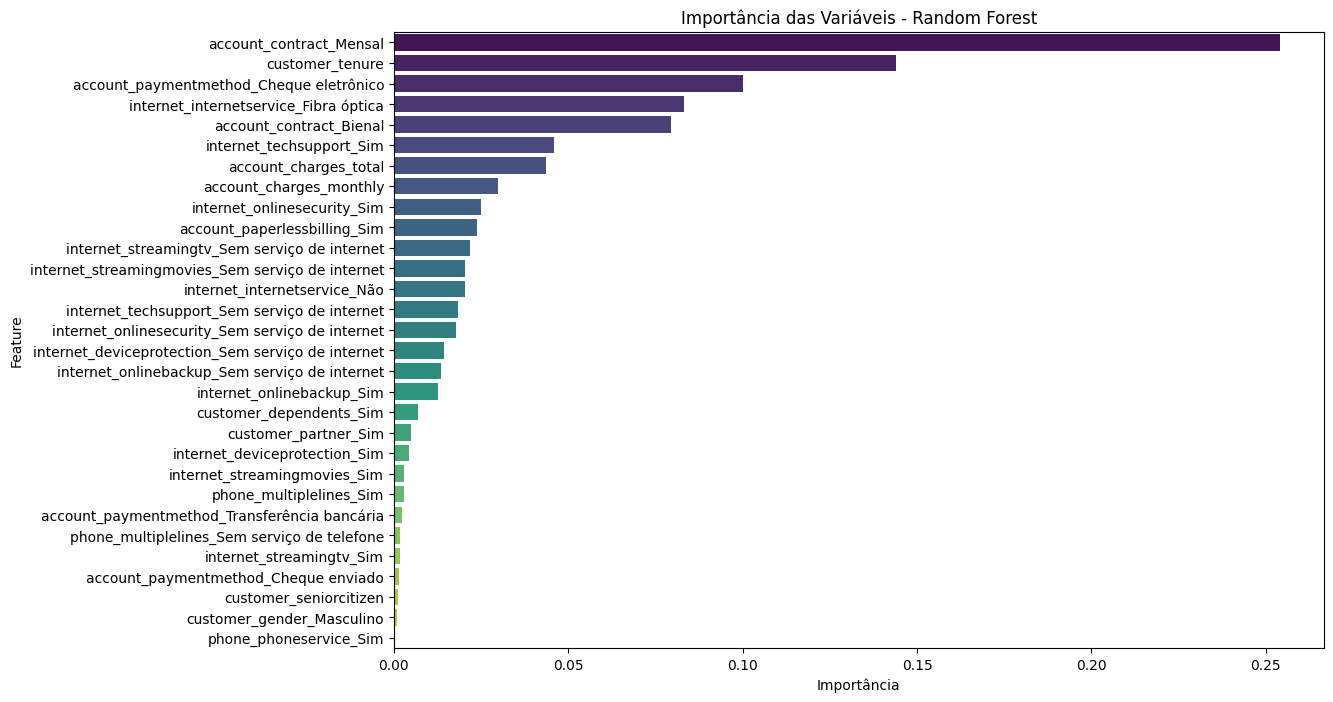

In [170]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importances_rf, hue='Feature', palette='viridis')
plt.xlabel('Importância')
plt.title('Importância das Variáveis - Random Forest');

## 📊 Análise Estratégica: Fatores de Churn e Planos de Ação

### 🔍 1. Principais Variáveis com Impacto na Evasão
**📌 Regressão Logística (Análise de Coeficientes):**

| Variável | Coeficiente | Impacto |
|----------|------------|---------|
| tenure | -1.61 | 📉 Redução de 161% na probabilidade de churn |
| Charges_Total | 0.89 | 📊 Aumento de 89% no risco de evasão |
| InternetService_Fiber optic | 0.72 | ⚠️ +72% probabilidade de cancelamento |
| Contract_Two year | -0.56 | 🛡️ Redução de 56% no churn |
| Charges_Monthly | -0.51 | 💰 Menor risco com aumento de gasto mensal |

**🌳 Random Forest (Importância das Features):**

| Variável | Importância | Ranking |
|----------|------------|---------|
| PaymentMethod_Electronic check | 0.15 | 🥇 1ª mais relevante |
| tenure | 0.13 | 🥈 2ª maior impacto |
| Contract_Two year | 0.11 | 🥉 3ª em importância |
| InternetService_Fiber optic | 0.08 | 📶 4ª posição |
| PaperlessBilling | 0.07 | 📧 5ª variável crítica |

### 🎯 2. Fatores Críticos de Evasão Consolidados

**📉 Fatores de Proteção (Reduzem Churn):**
- **⏳ Tempo de Relacionamento (tenure)**: Clientes veteranos 161% menos propensos a cancelar
- **📝 Contratos Longos**: Planos anuais/bi-anuais reduzem evasão em 56%
- **💳 Gastos Consistentes**: Maior ticket médio mensal diminui risco em 51%

**⚠️ Fatores de Risco (Aumentam Churn):**
- **📶 Internet Fibra Óptica**: 72% maior probabilidade de evasão
- **🧾 Pagamento via Cheque Eletrônico**: Método com maior impacto negativo
- **📧 Fatura Digital**: Correlacionado com +7% de risco de cancelamento

### 🚀 3. Estratégias de Retenção Prioritárias

**🎯 Programa "Primeiros 90 Dias"**
- **Foco**: Clientes com tenure < 3 meses
- **Ações**: Visitas proativas, mentorias técnicas, descontos progressivos
- **Meta**: Reduzir evasão inicial em 40%

**📝 Conversão para Contratos Longos**
- **Oferta**: 20% desconto em planos anuais + benefícios exclusivos
- **Segmento**: Clientes mensais com >6 meses de relação
- **Expectativa**: Aumentar retenção em 56%

**🛠️ Task Force Fibra Óptica**
- **Diagnóstico**: Pesquisa de satisfação específica
- **Soluções**: Melhoria técnica, pacotes promocionais, garantia de serviço
- **Objetivo**: Reduzir churn do segmento em 30%

**💳 Migração de Meios de Pagamento**
- **Incentivo**: 5% desconto para pagamentos automáticos
- **Foco**: Usuários de cheque eletrônico
- **Meta**: Converter 60% em 6 meses

### 📊 4. Métricas de Sucesso e Monitoramento

**🎯 KPIs Principais:**
- Taxa de churn mensal (<5%)
- Conversão para contratos longos (>25%)
- Satisfação clientes fibra (NPS >50)
- Migração meios pagamento (>60%)

**🔍 Monitoramento Contínuo:**
- Reavaliação trimestral dos modelos
- A/B testing das estratégias
- Análise granular por segmento

### ⚡ 5. Próximos Passos Imediatos

1. **🎯 Implementar scoring de risco** baseado no modelo Random Forest
2. **📋 Criar campanhas personalizadas** por perfil de cliente
3. **🔄 Estabelecer ciclo de feedback** contínuo com operação
4. **📊 Dashboard executivo** com métricas em tempo real

**💡 Conclusão Estratégica**: Priorizar clientes novos e usuários de fibra óptica, com foco na conversão para contratos longos e migração de meios de pagamento.